# Notebook 07

# Industrial Anomaly Detection using Isolation Forest

---

## Project

AI-based Anomaly Detection and Predictive Monitoring for Industrial Water Treatment Systems

---

## Objectives

This notebook develops an unsupervised anomaly detection model using Isolation Forest.

Tasks include:

- Loading processed data
- Training Isolation Forest
- Predicting anomalies
- Evaluating anomaly distribution
- Saving benchmark results

In [1]:
from pathlib import Path

import warnings

warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT/"data"/"processed"

RESULT_PATH = PROJECT_ROOT/"results"

MODEL_PATH = PROJECT_ROOT/"models"

RESULT_PATH.mkdir(exist_ok=True)

MODEL_PATH.mkdir(exist_ok=True)

In [3]:
train = pd.read_csv(DATA_PATH/"train_data.csv")

test = pd.read_csv(DATA_PATH/"test_data.csv")

X_train = train.drop(columns="Target")

X_test = test.drop(columns="Target")

y_test = test["Target"]

In [4]:
print(X_train.shape)

print(X_test.shape)

(1153375, 51)
(288344, 51)


In [5]:
iso = IsolationForest(

    n_estimators=300,

    contamination=0.05,

    random_state=42

)

iso.fit(X_train)

IsolationForest(contamination=0.05, n_estimators=300, random_state=42)

In [6]:
pred = iso.predict(X_test)

pred = np.where(

    pred==-1,

    1,

    0

)

In [7]:
results = X_test.copy()

results["True"] = y_test.values

results["Prediction"] = pred

results.head()

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,True,Prediction
0,0.695766,-0.602819,0.335952,0.606750,-0.046608,-0.248022,-0.785361,-0.092905,0.599198,0.321655,...,0.0,0.263217,-0.407415,0.291049,-0.099023,0.0,-0.091453,0.0,0,0
1,-1.565178,1.075201,0.335952,0.606750,-0.046608,-0.248022,-0.579222,-0.145340,0.619757,0.321655,...,0.0,0.205477,-0.140592,0.214762,-0.099023,0.0,-0.091453,0.0,0,0
2,0.571699,-0.503367,0.335952,0.606750,-0.046608,2.225950,-0.204925,-0.122035,0.609123,0.321655,...,0.0,0.121798,-0.514144,0.101149,-0.099023,0.0,-0.091453,0.0,0,0
3,0.690770,-0.803625,0.335952,0.606750,-0.046608,-0.270778,0.999344,-0.385377,0.599789,0.321655,...,0.0,0.067406,-0.780966,0.032440,-0.099023,0.0,-0.091453,0.0,0,0
4,-1.565178,1.775168,-2.880775,-1.648125,-0.046608,-0.276842,1.313974,0.306767,-1.651437,-3.020295,...,0.0,-6.145809,-3.769375,-6.142788,-0.099023,0.0,-0.091453,0.0,1,1


In [8]:
results.to_csv(

    RESULT_PATH/"isolation_predictions.csv",

    index=False

)

In [9]:
anomaly_rate = results["Prediction"].mean()

print(anomaly_rate)

0.04979122159642649


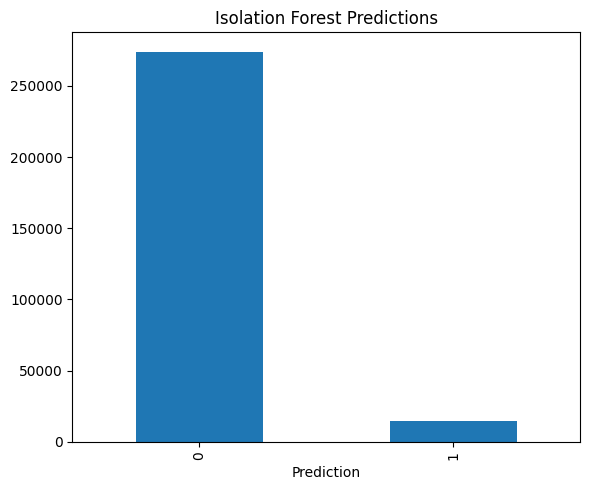

In [10]:
plt.figure(figsize=(6,5))

results["Prediction"].value_counts().plot(

    kind="bar"

)

plt.title("Isolation Forest Predictions")

plt.tight_layout()

plt.savefig(

    RESULT_PATH/"isolation_prediction_distribution.png",

    dpi=300

)

plt.show()

In [11]:
benchmark = pd.DataFrame({

    "Model":[

        "Isolation Forest"

    ],

    "Samples":[

        len(results)

    ],

    "Predicted Anomalies":[

        results["Prediction"].sum()

    ],

    "Anomaly Rate":[

        anomaly_rate

    ]

})

benchmark

,Model,Samples,Predicted Anomalies,Anomaly Rate
0,Isolation Forest,288344,14357,0.049791


In [12]:
benchmark.to_csv(
    RESULT_PATH/"isolation_benchmark.csv",
    index=False
)

In [13]:
joblib.dump(

    iso,

    MODEL_PATH/"isolation_forest.pkl"

)

['E:\\new\\hamid\\CV\\AI-based Anomaly Detection and Predictive Monitoring for Industrial Water Treatment Systems\\models\\isolation_forest.pkl']

# Conclusion

Isolation Forest has been successfully trained as an unsupervised anomaly detection baseline.

Outputs generated:

- isolation_predictions.csv
- benchmark_results.csv
- isolation_forest.pkl

These outputs will be used only for benchmarking purposes.

The supervised machine learning pipeline implemented in subsequent notebooks remains unchanged.